In [5]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LassoCV, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize





pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [6]:
# Fonction pour transformer et encoder les données
# def scale_encode(x, y=0):
#     encoder = OneHotEncoder(drop='first')
#     qualitative_vars = ['Vitesse']
#     numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
#     encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
#     encoded_columns = encoder.get_feature_names_out(qualitative_vars)
#     encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
#     X = pd.concat([x.drop(['Vitesse'], axis=1), encoded_df], axis=1)
#     return X

df = pd.read_csv('Data_Modelisation-3.csv')
df = df[df.Vitesse == 65]
# df.Vitesse = df.Vitesse.astype(str)

df = df.drop(["Vitesse"],axis = 1)

In [7]:
df.shape

(562, 9)

In [8]:
# c = []
# g = []
# cfl = []
# t = []
# for i in df.Contaminant.unique():
#     a = df[(df.Contaminant == i)  & (df.Glissement == 100)]["Moyenne CFL C"].median()
#     temp = df[(df.Contaminant == i) & (df.Glissement == 100)]['T° BDR (C)'].median()
#     for k in [40, 60,80]:
#         c+= [i]
#         g+= [k]
#         cfl+= [(a+0.015) if k==40 else ( (a+0.01) if k==60 else (a+0.005))]
#         t+=[temp]


# more_data = pd.DataFrame({
#               "Glissement" : g,
#              "Moyenne CFL C" : cfl,
#              'Moyenne G% [%]' : g,
#               'T° BDR (C)' : t,
#               "Contaminant" : c
#              })
# df = pd.concat([df, more_data], axis = 0)



In [9]:
X_o = df.drop(['Moyenne CFL F','Glissement',"hauteur (mm)"], axis=1)

In [10]:
# Neige fraiche (B)
nfb = X_o[X_o.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Neige fraiche (G)
nfg = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
ncg = X_o[X_o.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
ncb = X_o[X_o.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
ncc = X_o[X_o.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
ver = X_o[X_o.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
gla = X_o[X_o.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
slh = X_o[X_o.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Columns to drop in every modele


## Neige fraiche (B)

In [11]:
def descritisation_nfb(x):
    if x< 6:
        return "6"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

#### Attempt 1 (Attempt 1 tjrs avec la contrainte de continuité seul sans pénalisation)

Meilleur point de coupure: 10.0
Paramètres: a1=0.037456067077633826, b1=0.025565329420529553, c1=-0.0014495458512040092, a2=0.15809363194272122, b2=-0.001, c2=-0.004316390221942986
R² train: 0.5543784577498566
R² test: 0.8254971578596608


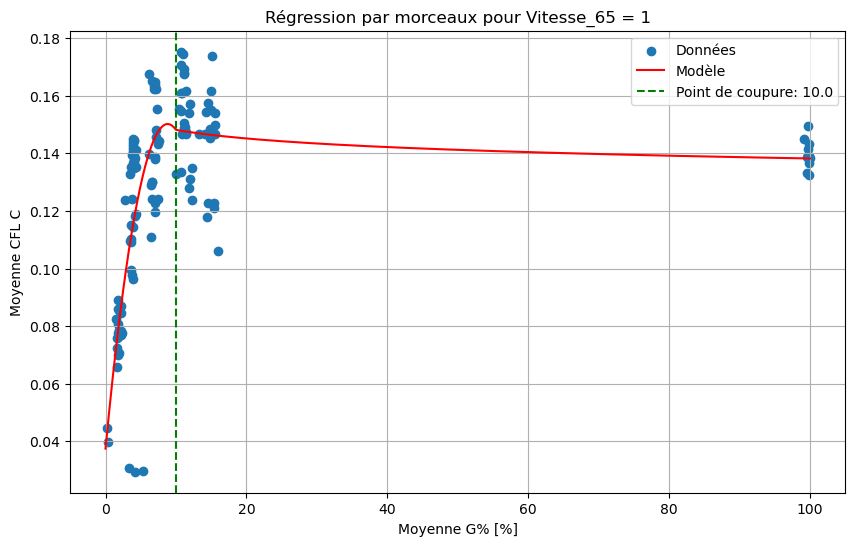

CPU times: total: 1.11 s
Wall time: 1.1 s


In [12]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)

    
    return mean_squared_error(y, y_pred) 


data = nfb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=13)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(10,11, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01,]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attepmt 2

Meilleur point de coupure: 11.666666666666666
Paramètres: a1=0.043888067995682324, b1=0.02151575740534032, c1=-0.0010284754560520631, a2=0.17505705309004346, b2=-0.008197361936840517
R² train: 0.5394957547125028
R² test: 0.8080829053637292


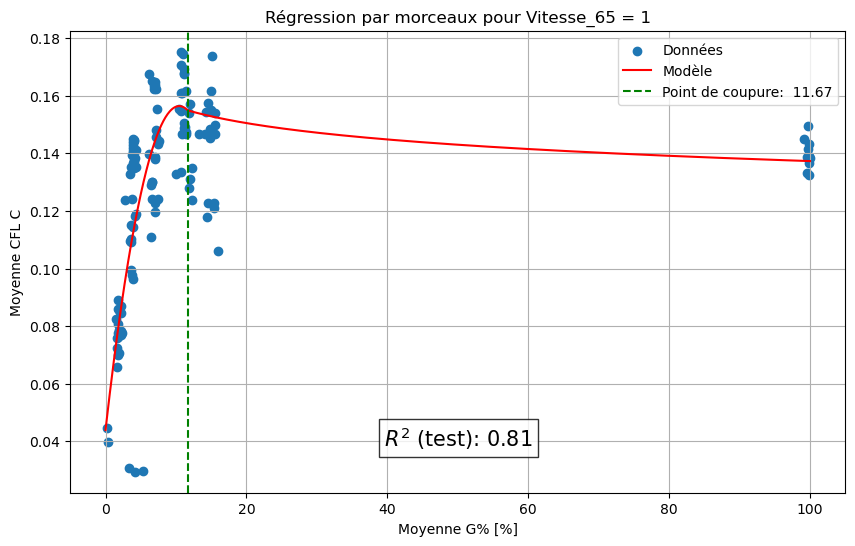

CPU times: total: 1.09 s
Wall time: 1.1 s


In [109]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + b2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred) 
    reg = 0.005 * np.sum(abs(params[3:])) + 0.0035*a1
    return mean_squared_error(y, y_pred) + 0.005*max_abscissa_diff + reg


data = nfb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=13)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,12, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, 0.01,]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  b2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +b2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k: .2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()

## Neige fraiche (G)

In [114]:
def descritisation_nfg(x):
    if x<3:
        return "3"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

#### Attempt 1

Meilleur point de coupure: 11.0
Paramètres: a1=0.03335367439646018, b1=0.024144591838340935, c1=-0.0011688019807153868, a2=0.16995537364625485, b2=0.0, c2=-0.005186310192808194
R² train: 0.8355207918579421
R² test: 0.874603202817572


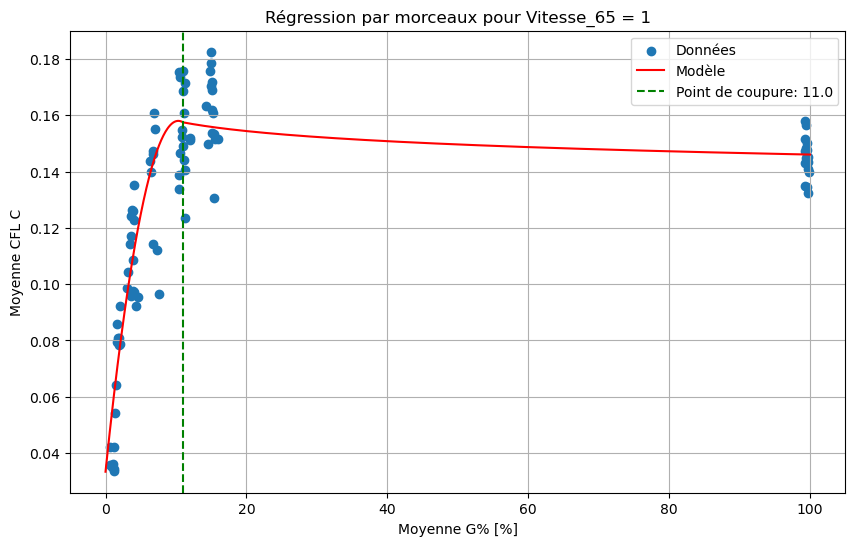

CPU times: total: 1 s
Wall time: 959 ms


In [25]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=13)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 13.0
Paramètres: a1=0.02806289199292669, b1=0.021056486840946718, c1=-0.0008096276183625333, a2=0.20131714370426784, b2=-0.014170646363599665
R² train: 0.8144964153902604
R² test: 0.8239226476385557


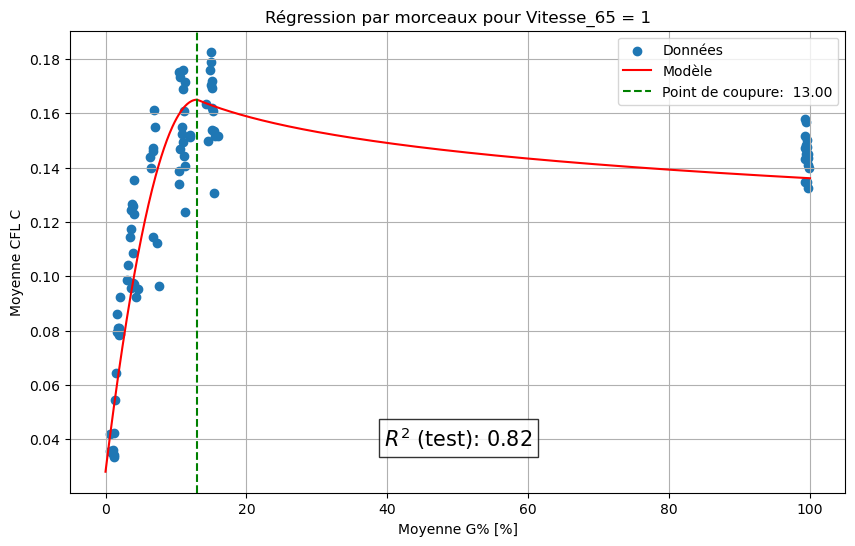

CPU times: total: 1.05 s
Wall time: 1.05 s


In [160]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + b2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred) 
    reg = 0.0003 * np.sum(abs(params[3:]))
    return mean_squared_error(y, y_pred) + 0.0005*max_abscissa_diff +reg


data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  b2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +b2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k: .2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

Meilleur point de coupure: 14.0
Paramètres: a1=0.04040672719019705, b1=0.017746423263960278, c1=-0.0006340118208024522, a2=0.19385214917750718, b2=0.0006729753714499822, c2=-0.011087979350472508
R² train: 0.8358426963421124
R² test: 0.8222167751349072


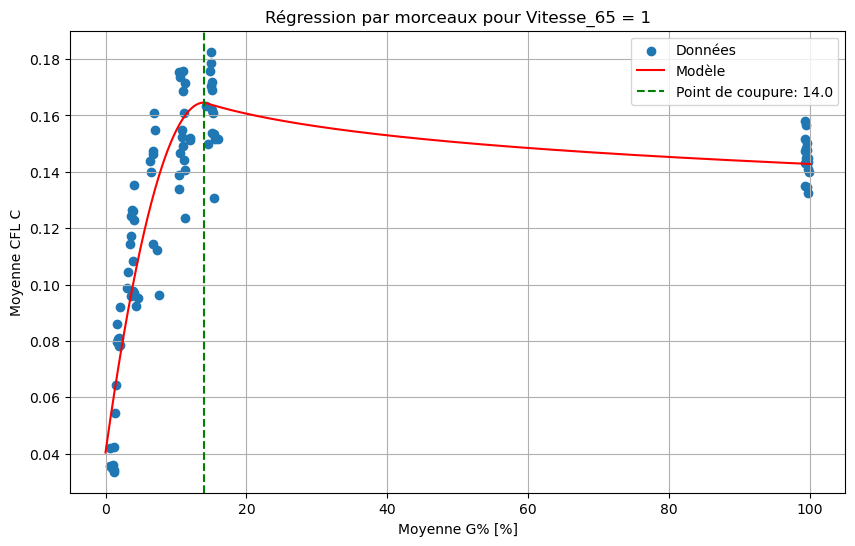

CPU times: total: 1.81 s
Wall time: 1.86 s


In [134]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0003 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.007*max_abscissa_diff +reg


data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=2) 

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(12,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01,]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

Meilleur point de coupure: 14.0
Paramètres: a1=0.040404936454674883, b1=0.017746600831801497, c1=-0.0006340109845432316, a2=0.193854894561668, b2=0.0006718434137871256, c2=-0.011088694095665085
R² train: 0.8358389300502028
R² test: 0.822218900596138


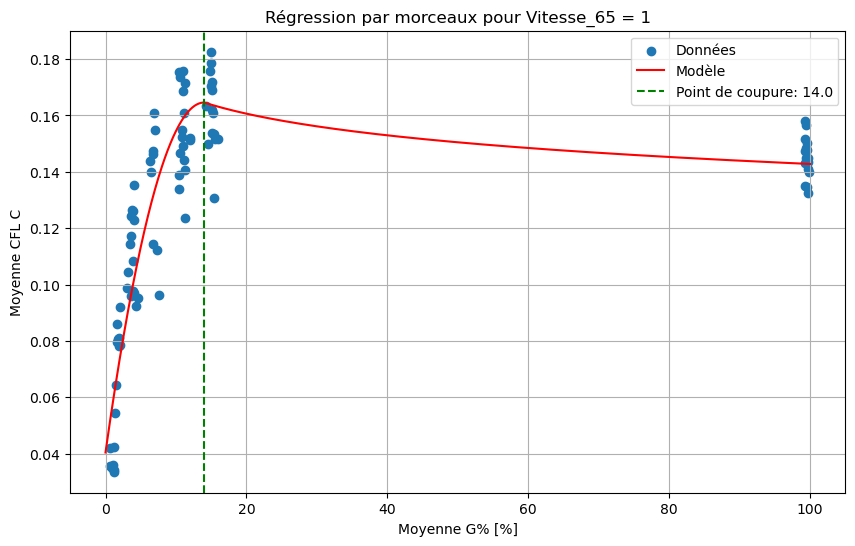

CPU times: total: 1.81 s
Wall time: 1.78 s


In [116]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0003 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.005*max_abscissa_diff +reg


data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=2) 

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(12,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01,]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

## N.C. (G)

In [275]:
def descritisation_ncg(x):
    if x<2:
        return "2"
    elif x< 5:
        return "5"
    elif x< 9:
        return "9"
    elif x< 12:
        return "12"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

#### Attempt 1

Meilleur point de coupure: 11.5
Paramètres: a1=-0.005563672331995728, b1=0.0324571667730357, c1=-0.001256598736166424, a2=0.23235853544764645, b2=0.0, c2=-0.012631281431126079
R² train: 0.8413638638483784
R² test: 0.8126492064701251


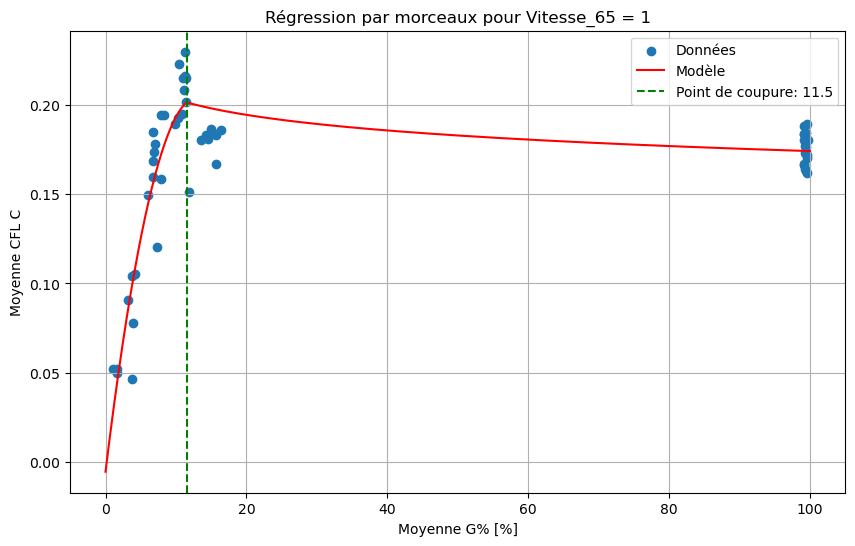

CPU times: total: 750 ms
Wall time: 735 ms


In [277]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = ncg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11.5,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 12.5
Paramètres: a1=-0.02825956424868745, b1=0.04074576653580479, c1=-0.0018153140831699281, a2=0.2266824071396478, b2=-0.001, c2=-0.011585850782123642
R² train: 0.8187695439791368
R² test: 0.8791382317809338


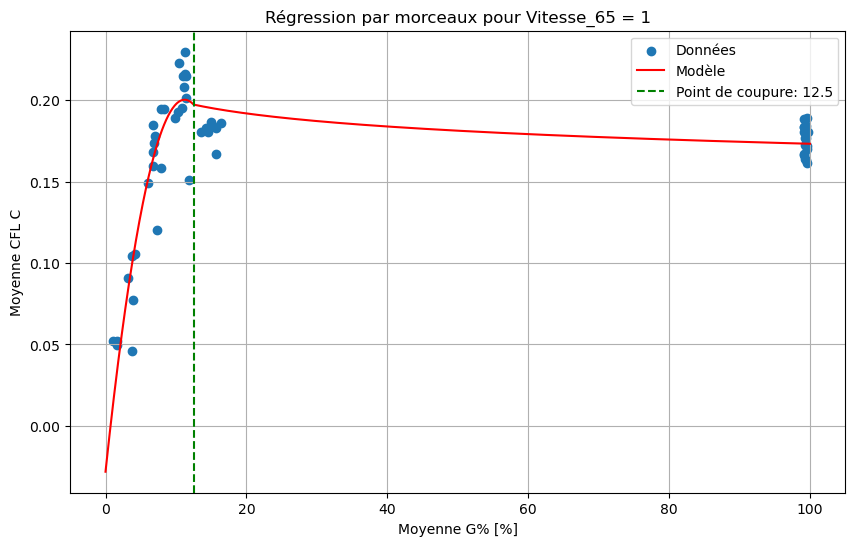

CPU times: total: 4.22 s
Wall time: 4.21 s


In [527]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.001 * np.sum(abs(params[:3])) - 0.003*abs(a1)
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff +reg


data = ncg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=40)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11.5,12.5, 20)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

## N.C. (B)

In [335]:
def descritisation_ncb(x):
    if x<2:
        return "2"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

####  Attempt 1

Meilleur point de coupure: 11.0
Paramètres: a1=0.025497653723876718, b1=0.030257040942711557, c1=-0.0012417192040362298, a2=0.2500720681646312, b2=0.0, c2=-0.017513270173092413
R² train: 0.8626327844925739
R² test: 0.9143296568837406


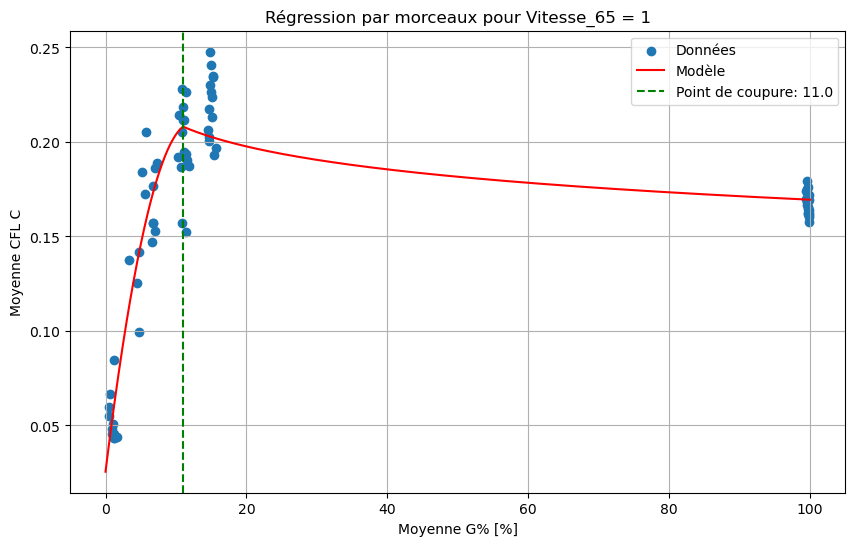

CPU times: total: 1.05 s
Wall time: 1.06 s


In [336]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = ncb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=40)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(10,11, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 14.526315789473685
Paramètres: a1=0.03503808578233005, b1=0.024313092539158216, c1=-0.0008277744043991564, a2=0.2781307962141946, b2=-0.001, c2=-0.024135214728891883
R² train: 0.8723009412314078
R² test: 0.9240939355442013


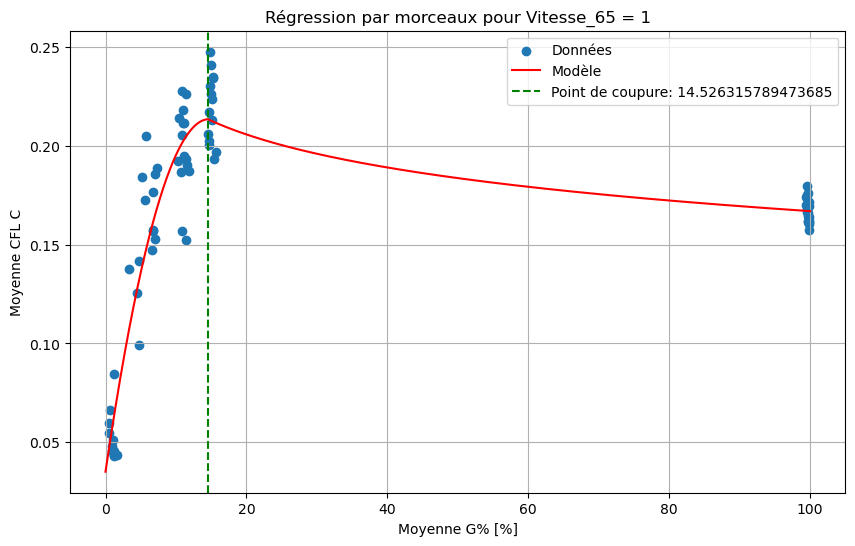

CPU times: total: 2.3 s
Wall time: 2.29 s


In [528]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.001 * np.sum(abs(params[:3]))
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff +reg


data = ncb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(12,15, 20)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

Meilleur point de coupure: 14.526315789473685
Paramètres: a1=0.0326823670387456, b1=0.025365900928837344, c1=-0.0008724233506027683, a2=0.2873890713117037, b2=-0.001, c2=-0.026281027340537926
R² train: 0.8850263401636577
R² test: 0.8852362719140439


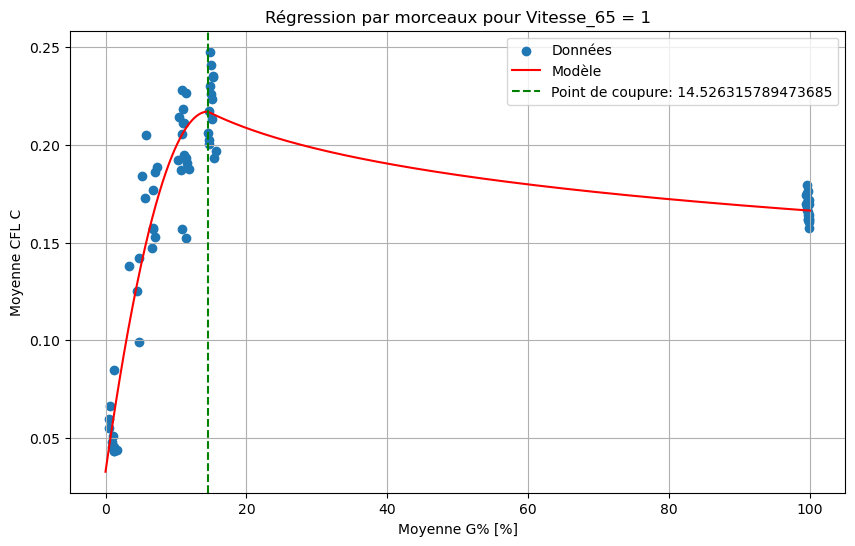

CPU times: total: 2.47 s
Wall time: 2.45 s


In [529]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.001 * np.sum(abs(params[:3]))
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff +reg


data = ncb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=0)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(12,15, 20)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

## NC.C.


In [55]:
def descritisation_ncc(x):
    if x<2:
        return "2"
    if x<4:
        return "4"
    if x<6:
        return "6"
    elif x< 8:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"


#### Attempt 1

Meilleur point de coupure: 9.081632653061224
Paramètres: a1=0.022541993959605502, b1=0.04858974478471735, c1=-0.002758693073724859, a2=0.28403741393039184, b2=0.0, c2=-0.021641805505190327
R² train: 0.8307758817025812
R² test: 0.8908856835363126


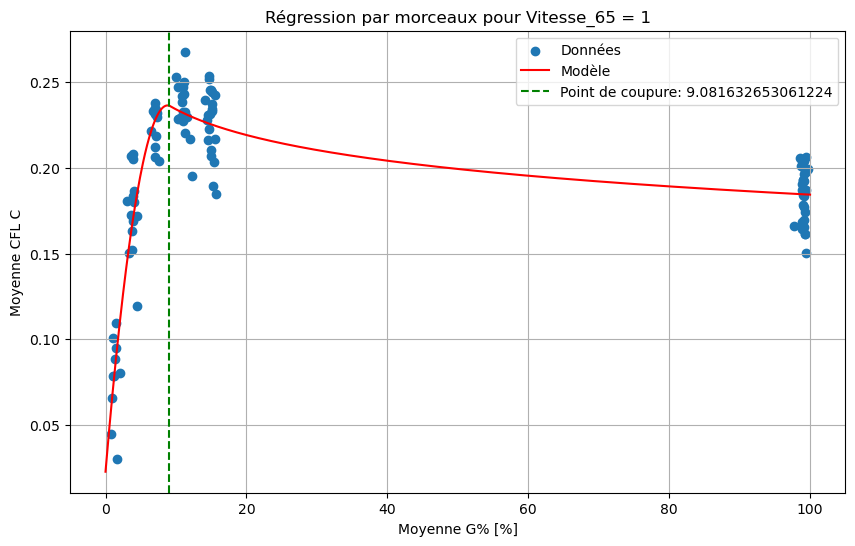

CPU times: total: 3.08 s
Wall time: 3.06 s


In [57]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = ncc
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncc)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(1,100, 50)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 13.0
Paramètres: a1=0.051245467008241584, b1=0.03435668022613107, c1=-0.0015607670831270285, a2=0.3076137185890924, b2=-0.0019087468284965956, c2=-0.02865594421061068
R² train: 0.8293307410984984
R² test: 0.7733311193297365


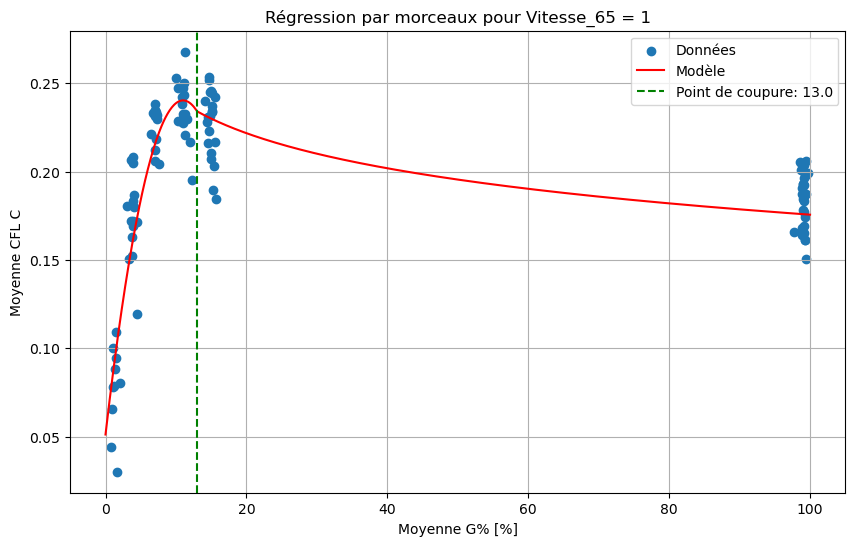

CPU times: total: 1.88 s
Wall time: 1.88 s


In [60]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0003 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff+reg


data = ncc
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncc)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=30)
# 30 75 5
# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

## Verglas

In [539]:
def descritisation_verglas(x):
    if x< 6:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

#### Attempt 1

Meilleur point de coupure: 15.0
Paramètres: a1=0.07158898989047788, b1=0.0089200043571719, c1=-0.00024945898268429, a2=0.1843691562481815, b2=0.0, c2=-0.012964446556882888
R² train: 0.6988364898150607
R² test: 0.4958825632102636


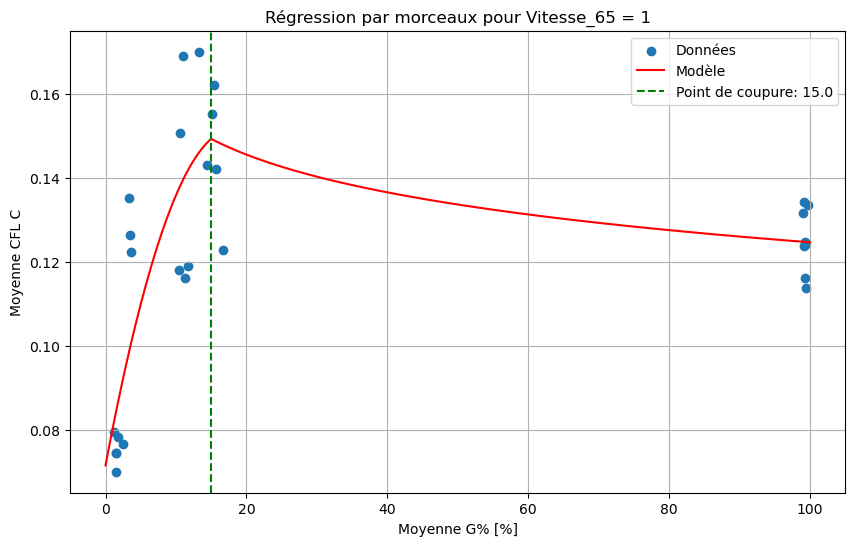

CPU times: total: 1.02 s
Wall time: 1.03 s


In [537]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = ver
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=64)#  36  57 64 

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 14.444444444444445
Paramètres: a1=0.07285607379567761, b1=0.010551750533673753, c1=-0.000392172963746611, a2=0.17012517760376106, b2=-0.001, c2=-0.009990852192722532
R² train: 0.606955121113194
R² test: 0.7961266945294264


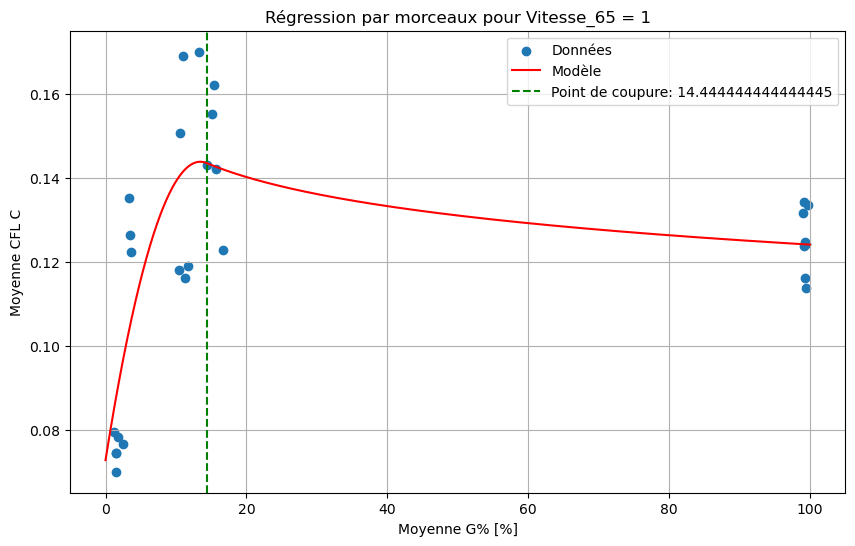

CPU times: total: 2.28 s
Wall time: 2.29 s


In [540]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0005 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff


data = ver
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_verglas)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=19)# 19 20 61
# 
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(10,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

## Glace

In [26]:
def descritisation_glace(x):
    if x< 6:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

#### Attempt 1

Meilleur point de coupure: 13.0
Paramètres: a1=-0.02797195493212994, b1=0.017930166754697913, c1=-0.0006171967268662924, a2=0.15055257820262813, b2=0.0, c2=-0.01939165466147937
R² train: 0.7690039952497825
R² test: 0.853580981957648


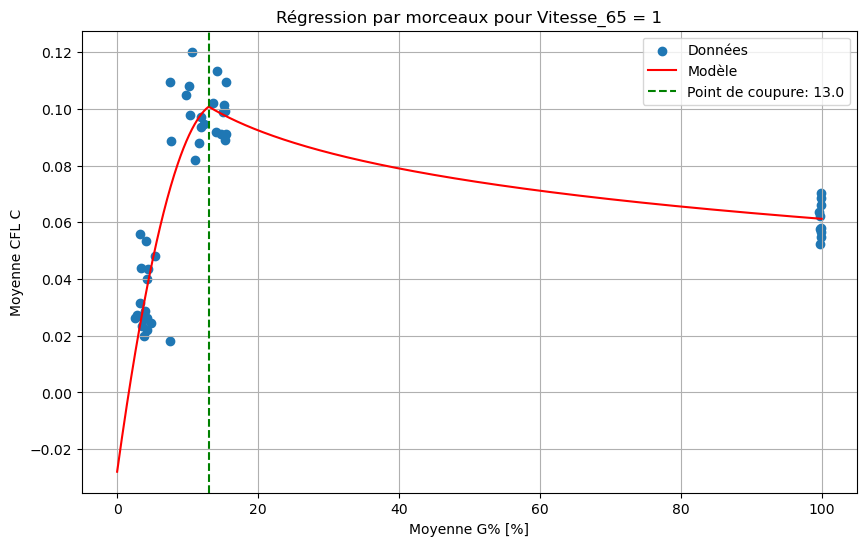

CPU times: total: 4.48 s
Wall time: 4.46 s


In [27]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = gla
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_glace)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=40)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13,100, 100)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 12.11111111111111
Paramètres: a1=-0.033408299143142174, b1=0.021203352603202837, c1=-0.0008738861824291153, a2=0.1314783444990364, b2=-48.4368513423654, c2=-0.014542684248916431
R² train: 0.7399234908102423
R² test: 0.8795309878470609


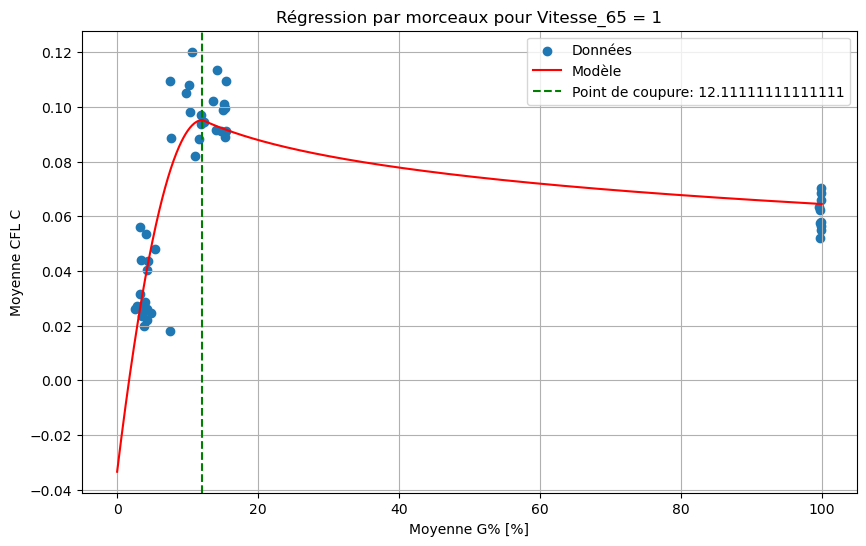

CPU times: total: 8.11 s
Wall time: 8.11 s


In [40]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0020 * np.sum(abs(params[3:]))
    
    return mean_squared_error(y, y_pred) + 0.003*max_abscissa_diff + reg


data = gla
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_glace)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=0)# 19 20 61
# 40 0 11 26c0.002 90
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

## slush

In [515]:
def descritisation_slh(x):
    if x<0.5:
        return "0.5"
    if x<1:
        return "1"
    if x<4:
        return "4"

    elif x< 14:
        return "14"
    else:
        return "more"


#### Attempt 1

Meilleur point de coupure: 15.555555555555555
Paramètres: a1=0.007668129105366956, b1=0.013618740616328704, c1=-0.0003761994192025076, a2=0.12007179833609881, b2=0.0, c2=0.0030652899532900195
R² train: 0.7345201110436284
R² test: 0.7289014280129463


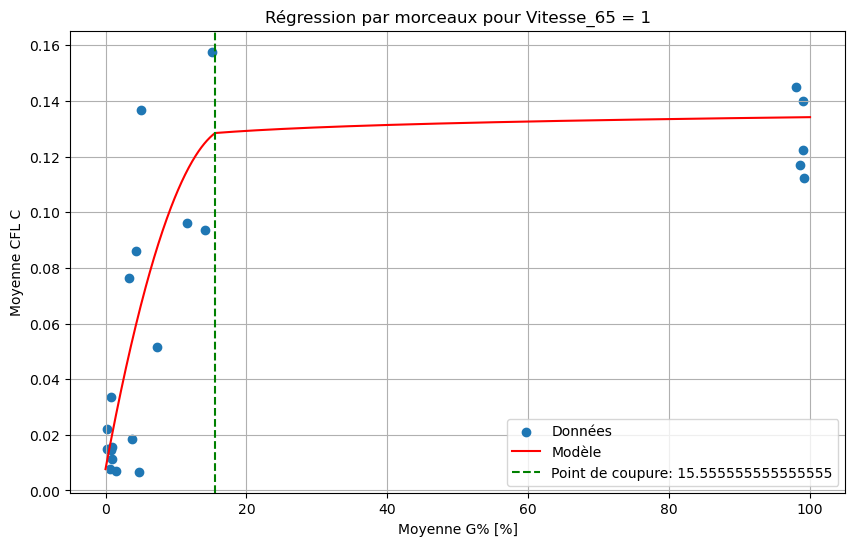

CPU times: total: 812 ms
Wall time: 817 ms


In [516]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = slh
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_slh)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=68)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(14,16, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 12.777777777777779
Paramètres: a1=0.011007034968593165, b1=0.012213285615798595, c1=-0.000465400338150339, a2=0.05262467137019173, b2=0.014940675925267308, c2=0.015093707662323525
R² train: 0.703712528625986
R² test: 0.7028763626986025


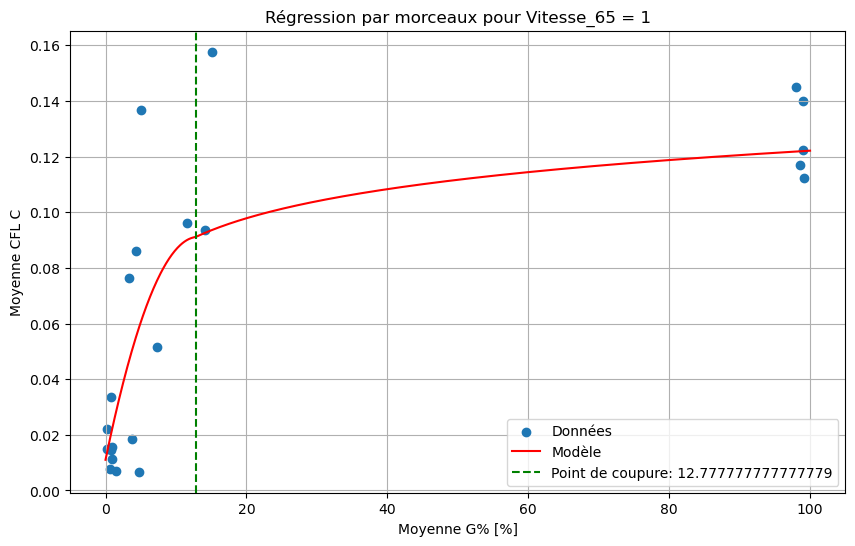

CPU times: total: 1.56 s
Wall time: 1.56 s


In [518]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0020 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.003*max_abscissa_diff + reg


data = slh
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_slh)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=0)# 19 20 61
# 40 0 11 26c0.002 90
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()